In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
data = pd.read_csv("delhi-weather-aqi-2025.csv")
print(data.head())


     date_ist time_ist     location      lat     lon  temp_c  humidity  \
0  01/01/2025     0:00  Anand Vihar  28.6469  77.316     8.1       100   
1  01/01/2025     1:00  Anand Vihar  28.6469  77.316     7.7       100   
2  01/01/2025     2:00  Anand Vihar  28.6469  77.316     7.5       100   
3  01/01/2025     3:00  Anand Vihar  28.6469  77.316     7.8        99   
4  01/01/2025     4:00  Anand Vihar  28.6469  77.316     7.3       100   

   pressure_mb  windspeed_kph condition_text description  aqi_index  pm2_5  \
0        995.4            2.9   Mainly clear  WMO Code 1        197  185.8   
1        994.7            3.2       Overcast  WMO Code 3        198  174.6   
2        994.3            4.5       Overcast  WMO Code 3        199  164.4   
3        994.1            6.0       Overcast  WMO Code 3        200  156.5   
4        993.8            6.8       Overcast  WMO Code 3        200  149.5   

    pm10    co   no2  
0  188.6  1907  56.7  
1  177.4  1669  44.8  
2  166.7  1493  3

In [ ]:
X = data[['temp_c', 'humidity', 'pressure_mb',
          'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2']]

y = data['aqi_index']


In [ ]:
X = X.dropna()
y = y[X.index]


In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


Mean Absolute Error (MAE): 93.22106466609425
Mean Squared Error (MSE): 31869.824264663097
R2 Score: 0.7027159824097285


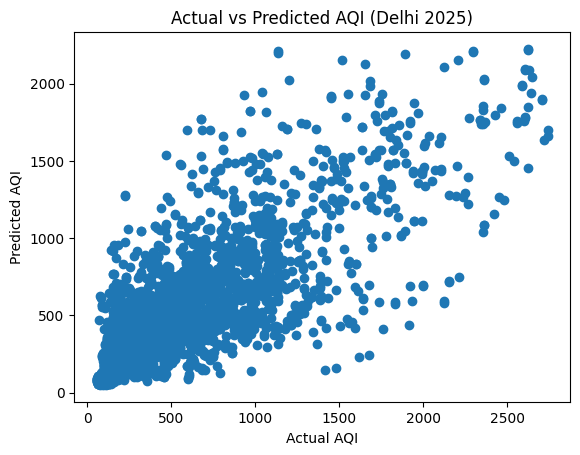

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Delhi 2025)")
plt.show()


In [ ]:
results = pd.DataFrame({
    "Actual AQI": y_test,
    "Predicted AQI": y_pred
})

results.to_csv("regression_results.csv", index=False)
print("Results saved to regression_results.csv")


Results saved to regression_results.csv
